# TidyTuesday week 10 - March 10, 2026
## How Likely is 'likely'? - Exploring quiz data 

Show the aboslute ranking values for each of the 19 phrases
ranked by highest median ranking value. 


In [11]:
# -- 1. Libraries ----
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -- 2. Load TT data ---

absolute_judgements = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-10/absolute_judgements.csv')
pairwise_comparisons = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-10/pairwise_comparisons.csv')
respondent_metadata = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-03-10/respondent_metadata.csv')

# make copy for playing with
abs_j = absolute_judgements.copy()

# quick look 
print(abs_j.shape)
print(abs_j.head())


(98306, 4)
   response_id                term  probability  order
0         5177       Little Chance           20      1
1         5177    Almost No Chance            9      2
2         5177       Remote Chance           18      3
3         5177          May Happen           44      4
4         5177  Chances are Slight           27      5


In [12]:
# --3. Prep the data ---

# prep the order the phrases will appear in plot (lowest to highest)
# ranking 
phrase_order = (
    abs_j.groupby('term')['probability']
    .median()
    .sort_values()
    .index # keep the names 
    .to_list()
)

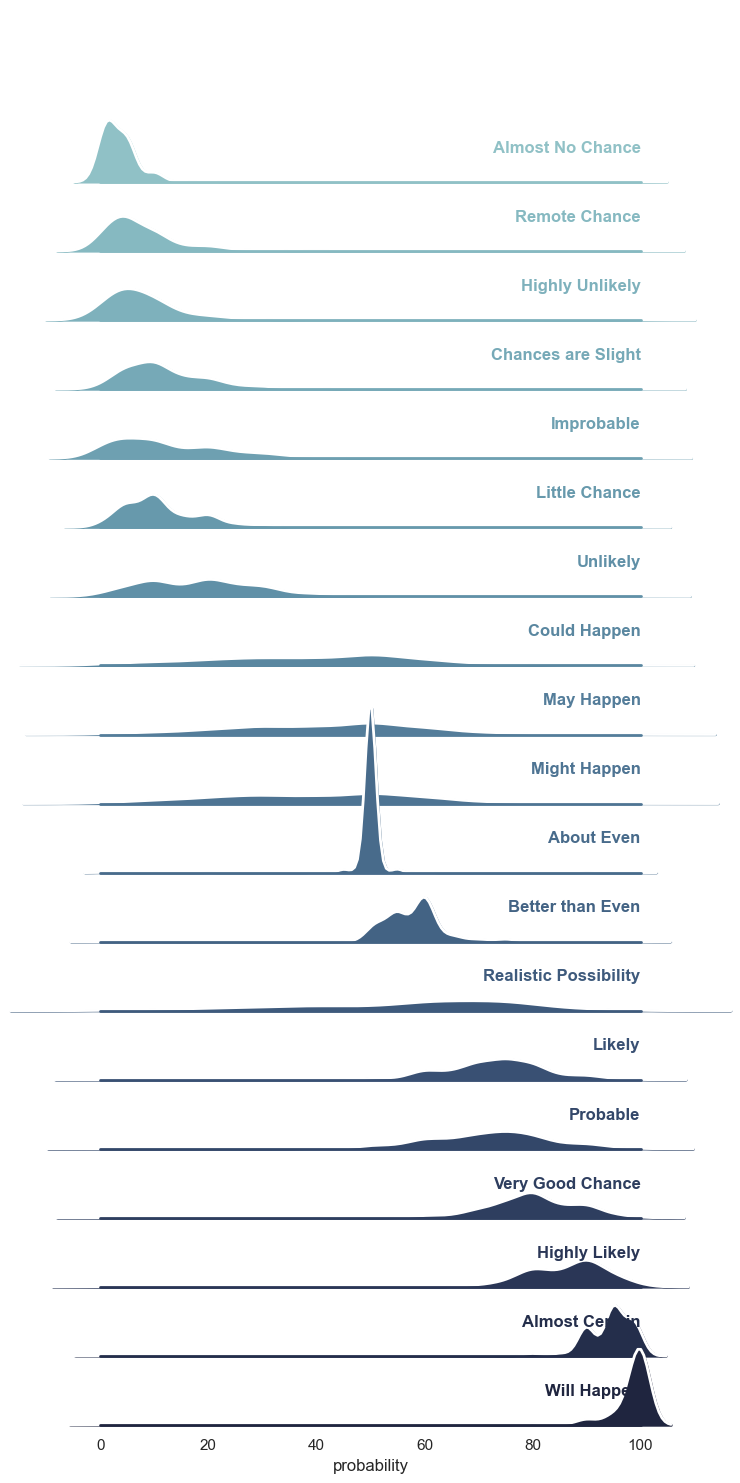

In [16]:
# --4. Prepare the ridgeline plot ---

#theming
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# colour palette
pal = sns.cubehelix_palette(19, rot=-.25, light=.7)

# initialize the facetgrid object
g = sns.FacetGrid(
    abs_j,
    row="term", 
    hue="term", 
    row_order=phrase_order, 
    hue_order=phrase_order, 
    aspect=8, 
    height=0.8, 
    palette=pal)

# draw the densities 
# filled shape
g.map(sns.kdeplot, "probability",
      bw_adjust=1.5, clip_on=False,        
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "probability", clip_on=False, color="w", lw=2, bw_adjust=1.5)

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(1, .2, label, fontweight="bold", color=color,
            ha="right", va="center", transform=ax.transAxes)

g.map(label, "probability")

g.figure.subplots_adjust(hspace=-0.6)
g.set_titles("")
g.set(yticks=[], ylabel="", xlim=(0, 100))
g.despine(bottom=True, left=True)

plt.show()